In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import networkx as nx
data = pd.read_excel('/kaggle/input/datasets/ewwshika/eta-graph/final_normalized_graph.csv.xlsx')
main = pd.read_csv('/kaggle/input/datasets/ewwshika/maindataset/delivery_data.csv')


In [ ]:
data.head(5)

# Creating a graph of all the hubs as nodes

In [ ]:
G = nx.from_pandas_edgelist(
    data,
    source='source_number',
    target='destination_number', create_using = nx.DiGraph)

# Calculating Betweenness Centrality 

In [ ]:
bwfactor = nx.betweenness_centrality(G)
bwdata = pd.DataFrame(bwfactor.items(), columns=['node', 'bwcentrality'])
bwdata = bwdata.sort_values('bwcentrality', ascending=False)

bwdata.head(10)

# Calculating Closeness Centrality 

In [ ]:
closenessfactor = nx.closeness_centrality(G)
closenessdata = pd.DataFrame(closenessfactor.items(), columns=['node', 'closeness'])
closenessdata = closenessdata.sort_values('closeness', ascending=False)
closenessdata.head(10)

# Calculating Degree Centrality 

In [ ]:
degreefactor = nx.degree_centrality(G)
degreedata = pd.DataFrame(degreefactor.items(), columns=['node', 'degree'])
degreedata = degreedata.sort_values('degree', ascending=False)
degreedata.head()

In [ ]:
top_in = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]
print(top_in)
top_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]
print(top_out)
top_overall = sorted(G.degree(), key=lambda x: x[1], reverse=True) [:10]
print(top_overall)

In [ ]:
data1 = pd.DataFrame()

# Chronically delayed corridors
(actual transit time exceeds OSRM by more than 20%)

In [ ]:
corridors = data.loc[:, ['actual_time', 'osrm_time','source_number', 'destination_number', 'osrm_time', 'actual_time']]
corridors['delay_ratio'] = (data['actual_time'] / data['osrm_time'])
data['delay_ratio'] = (data['actual_time'] / data['osrm_time'])
data1['delay_ratio'] = (data['actual_time'] / data['osrm_time'])
chronic_corridors = corridors[corridors['delay_ratio'] > 1.2].sort_values('delay_ratio', ascending=False)
chronic_corridors.loc[:, ['source_number', 'destination_number', 'delay_ratio']].sample(10)

In [ ]:
#troublesome corridors
corridors['delay_ratio'].quantile(0.90)

In [ ]:
#severe corridors
corridors['delay_ratio'].quantile(0.95)

In [ ]:
# critical corridors
corridors['delay_ratio'].quantile(0.99)

#  Hubs with most SLA breaches


In [ ]:
data['delay_hours'] = (data['actual_time'] - data['osrm_time']).clip(lower=0)

source_delay = (data.groupby('source_number')['delay_hours'].sum().reset_index().rename(columns={'source_number':'hub'}))

dest_delay = (data.groupby('destination_number')['delay_hours'].sum().reset_index().rename(columns={'destination_number':'hub'}))

hub_delay = pd.concat([source_delay, dest_delay])

hub_delay = (hub_delay.groupby('hub')['delay_hours'].sum().reset_index().sort_values('delay_hours', ascending=False))

In [ ]:
data1['delay_hours'] = (data1.merge(hub_delay, on='hub', how='left')['delay_hours'])

In [ ]:
delay_ratio_thresh = data1['delay_ratio'].quantile(0.75)
delay_hours_thresh = data1['delay_hours'].quantile(0.75)

data1['sla_breach'] = (
    (data1['delay_ratio'] > delay_ratio_thresh) &
    (data1['delay_hours'] > delay_hours_thresh)
).astype(int)

In [ ]:
total_network_delay = hub_delay['delay_hours'].sum()
data1['sla_breach_contribution'] = (hub_delay['delay_hours']/ total_network_delay * 100)

# Developing a Framework to Find chokepoints 

In [ ]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
clustering = nx.clustering(G.to_undirected())
closeness_dict = dict(zip(closenessdata['node'], closenessdata['closeness']))
bw_dict = dict(zip(bwdata['node'],bwdata['bwcentrality']))
degree_dict = dict(zip(degreedata['node'], degreedata['degree']))

hub_metrics = pd.DataFrame({
    'hub': list(G.nodes()),
    'betweenness': [bw_dict[n] for n in G.nodes()],
    'degrees': [degree_dict[n] for n in G.nodes()],
    'clustering': [clustering[n] for n in G.nodes()],
    'closeness': [closeness_dict[n] for n in G.nodes()]
})

hub_ops = data1.groupby('hub').agg(
    total_delay_hrs    = ('delay_hours',         'sum'),
    sla_breach_contrib = ('sla_breach_contribution', 'mean'),
).reset_index()

hub_metrics = hub_metrics.merge(hub_ops, on='hub', how='left')
hub_metrics[['total_delay_hrs', 'sla_breach_contrib']] = \
    hub_metrics[['total_delay_hrs', 'sla_breach_contrib']].fillna(0)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

structural_cols  = ['betweenness', 'degrees', 'closeness', 'clustering']
operational_cols = ['total_delay_hrs', 'sla_breach_contrib']

hub_metrics[structural_cols]  = MinMaxScaler().fit_transform(hub_metrics[structural_cols])
hub_metrics[operational_cols] = MinMaxScaler().fit_transform(hub_metrics[operational_cols])

In [ ]:
hub_metrics['structural_score'] = (
    0.50 * hub_metrics['betweenness']
  + 0.25 * hub_metrics['degrees']
  + 0.15 * hub_metrics['closeness']
  + 0.10 * (1 - hub_metrics['clustering'])
)

hub_metrics['performance_score'] = (
    0.40 * hub_metrics['total_delay_hrs']
  + 0.60 * hub_metrics['sla_breach_contrib']
)

hub_metrics['bottleneck_score'] = (
    0.50 * hub_full['structural_score']
  + 0.50 * hub_full['performance_score']
).round(6)

In [ ]:
bottleneck_map = hub_metrics.set_index('hub')['bottleneck_score']
data1['bottleneck_score'] = data1['hub'].map(bottleneck_map)

In [ ]:
data1.sort_values('bottleneck_score', ascending=False).head(5)

In [ ]:
data1.sort_values('sla_breach_contribution', ascending=False).head(5)

# csv output

In [ ]:
import json

with open('/kaggle/input/datasets/ewwshika/hubssss/hubs.json') as f:
    hub_dict = json.load(f)

hub_compiled = pd.DataFrame(
    list(hub_dict.items()),
    columns=['hub_name', 'hub_number']
)

hub_compiled.head()

In [ ]:
data1.rename(columns={'hub': 'hub_number'}, inplace=True)
data1 = data1.sort_values('hub_number')
merge1 = pd.merge(data1, bwdata, left_on='hub_number', right_on='node', how='outer')
merge1.drop(columns={'node'}, inplace=True)
merge2 = pd.merge(merge1, closenessdata, left_on='hub_number', right_on='node', how='outer')
merge2.drop(columns={'node'}, inplace=True)
merge3 = pd.merge(merge2, degreedata, left_on='hub_number', right_on='node', how='outer')
merge3.drop(columns={'node'}, inplace=True)

hub_features = pd.merge(hub_compiled, merge3, on='hub_number', how='outer')


hub_features.rename(columns={
    'bwcentrality': 'betweenness_centrality',
    'closeness' : 'closeness_centrality', 
    'degree' : 'degree_centrality'
}, inplace=True)

hub_features.sample(10)

In [ ]:
hub_features.to_csv('hub-features.csv',index=False)

In [ ]:
hub_features.sort_values('bottleneck_score', ascending=False).head(5)

# Top 10 Bottleneck Hubs

In [ ]:
top10 = hub_features.sort_values('bottleneck_score', ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    top10['hub_name'],
    top10['bottleneck_score']
)

plt.xlabel('Bottleneck Score')
plt.ylabel('Hub')
plt.title('Top 10 Bottleneck Hubs')
plt.gca().invert_yaxis()

plt.show()

In [ ]:
top_hubs = set(hub_features.nlargest(10, 'bottleneck_score')['hub_number'])

G_top = G.subgraph(top_hubs)

pos = nx.spring_layout(G_top, seed=42)

score_map = hub_features.set_index('hub_number')['bottleneck_score']

sizes = [
    score_map.loc[node] * 5000
    for node in G_top.nodes()
]

plt.figure(figsize=(10, 8))

nx.draw(
    G_top,
    pos,
    node_size=sizes,
    with_labels=True,
    arrows=True
)

plt.title("Top 10 Bottleneck Hubs")
plt.show()

# Hubs ranked by SLA Breaches

In [ ]:
top10 = hub_features.sort_values('sla_breach_contribution', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top10['hub_name'],
    top10['sla_breach_contribution']
)

plt.xlabel('SLA Breach Score')
plt.ylabel('Hub')
plt.title('Top 10 Hubs with SLA Breaches')
plt.gca().invert_yaxis()

plt.show()

# Graph of chronic corridors

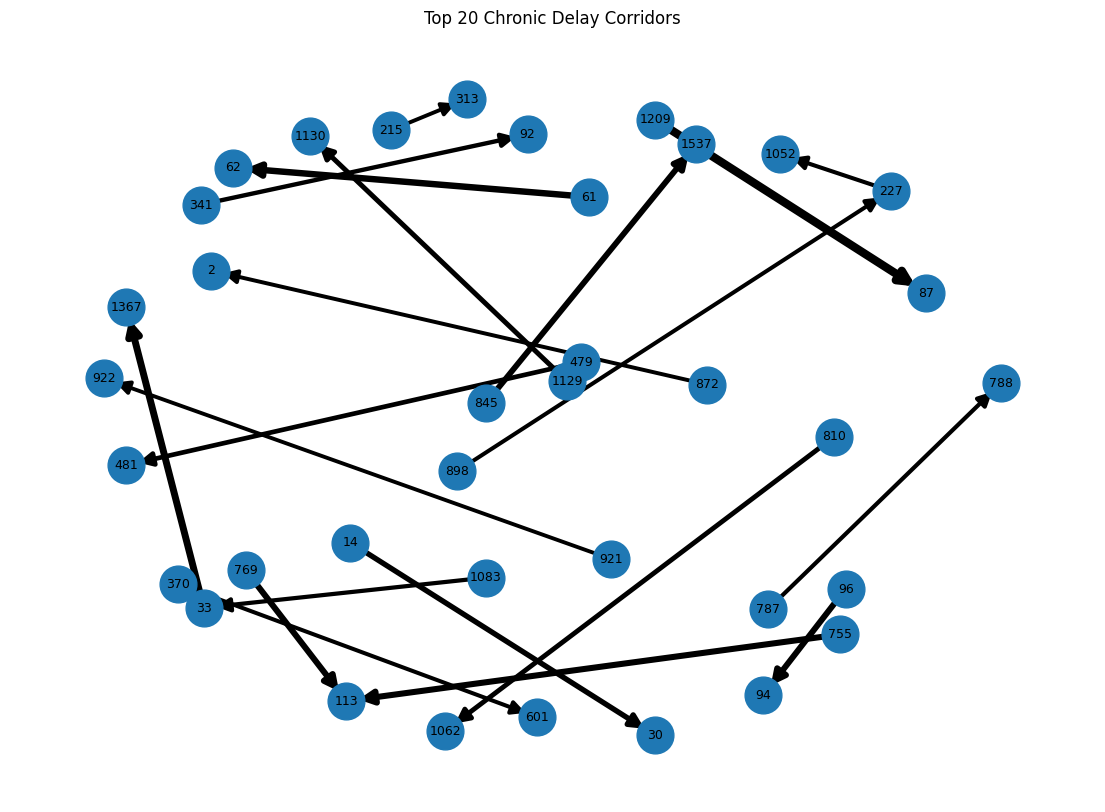

In [155]:
corridors = (
    data.groupby(['source_number', 'destination_number'])
    .agg(
        avg_delay_ratio=('delay_ratio', 'mean'),
        shipments=('delay_ratio', 'size')
    )
    .reset_index()
)

chronic_corridors = corridors.sort_values('avg_delay_ratio',ascending=False)
top_corridors = chronic_corridors.head(20)

G_delay = nx.from_pandas_edgelist(
    top_corridors,
    source='source_number',
    target='destination_number',
    edge_attr='avg_delay_ratio',
    create_using=nx.DiGraph()
)

pos = nx.spring_layout(G_delay,seed=42, k=1)

edge_widths = []

for _, _, d in G_delay.edges(data=True):
    width = np.log1p(d['avg_delay_ratio'])

    edge_widths.append(width)

max_width = max(edge_widths)
edge_widths = [1 + (w / max_width) * 5 for w in edge_widths]
plt.figure(figsize=(14,10))

nx.draw_networkx_nodes(
    G_delay,
    pos,
    node_size=700
)

nx.draw_networkx_labels(
    G_delay,
    pos,
    font_size=9
)

nx.draw_networkx_edges(
    G_delay,
    pos,
    width=edge_widths,
    arrows=True,
    arrowsize=20
)

plt.title("Top 20 Chronic Delay Corridors")
plt.axis('off')
plt.show()